<a href="https://colab.research.google.com/github/davacam/Inteligencia_Artificial/blob/main/Tercer%20Corte/TrabajoClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final de Machine Learning: Detección de Fraude Bancario

**Integrantes**
* Luisa Gonzalez Delgado
* Karol Caicedo Moreno
* Dairon Valencia Campaz
* Elkin Andres Chalarca

## 1. Título y descripción del problema
El problema central es la detección automatizada de fraudes bancarios. En el entorno financiero, identificar si una transacción es legítima o fraudulenta a partir de características operativas (monto, hora, frecuencia, distancia) es un problema clásico de **Clasificación Binaria**. La latencia y precisión en esta detección son críticas para mitigar pérdidas económicas y evitar bloqueos innecesarios a clientes legítimos.

## 2. Objetivo del trabajo

Investigar, implementar y evaluar el algoritmo **Random Forest Classifier** para identificar transacciones fraudulentas. Se busca optimizar sus hiperparámetros para equilibrar la compensación sesgo-varianza (Bias-Variance Tradeoff), garantizando que el modelo generalice correctamente sobre datos no vistos, previniendo el sobreajuste y subajuste.

## 3. Descripción del conjunto de datos
El dataset contiene 500 registros y 5 variables:
* `Valor_Transaccion` (Numérica continua): Monto de la operación.
* `Hora_Del_Dia` (Numérica discreta): Hora en formato 24h.
* `Numero_Transacciones_Diarias` (Numérica discreta): Frecuencia de uso del usuario.
* `Distancia_Geografica` (Numérica continua): Distancia respecto a la ubicación habitual del usuario.
* `Fraude` (Categórica binaria): Variable objetivo (SI/NO).

## 4. Fundamentación e Investigación del Modelo (Random Forest)
**Fundamento Matemático:**
Random Forest es un algoritmo de aprendizaje supervisado basado en el método de ensamble conocido como **Bagging (Bootstrap Aggregating)**. En lugar de depender de un solo Árbol de Decisión (que es altamente propenso al sobreajuste), Random Forest construye múltiples árboles.
Para cada árbol, selecciona una muestra aleatoria de los datos con reemplazo (Bootstrap). Durante la construcción de cada nodo en el árbol, la división óptima de los datos se decide evaluando un subconjunto aleatorio de características y calculando la reducción de la **Impureza de Gini**:
$$ Gini(p) = 1 - \sum_{i=1}^{J} p_i^2 $$
Donde $p_i$ es la probabilidad de que un elemento pertenezca a la clase $i$. El modelo final clasifica tomando la "votación mayoritaria" de todos los árboles del bosque.

**Comparación y Justificación de la Elección:**
* **Frente a Regresión Logística:** Random Forest puede capturar relaciones no lineales complejas (ej. el fraude ocurre a altas horas de la noche solo si la distancia es lejana), algo que la Regresión Logística no puede hacer sin transformaciones polinómicas previas.
* **Frente a Support Vector Machines (SVM):** A diferencia de SVM o K-Nearest Neighbors (KNN), Random Forest **no requiere normalización o estandarización** de los datos, ya que no se basa en el cálculo de distancias euclidianas, sino en umbrales de corte (ej. `Distancia > 150`).
* **Supuestos y Limitaciones:** Asume que los árboles individuales no están altamente correlacionados. Su principal limitación es que es un modelo de "caja negra"; no proporciona una ecuación matemática simple para explicar una predicción individual, a diferencia de la Regresión Lineal.

Dimensiones del dataset: (500, 5)


/tmp/ipykernel_415/1054137811.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fraude', ax=axes[0], palette='viridis')
/tmp/ipykernel_415/1054137811.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Fraude', y='Valor_Transaccion', ax=axes[1], palette='viridis')


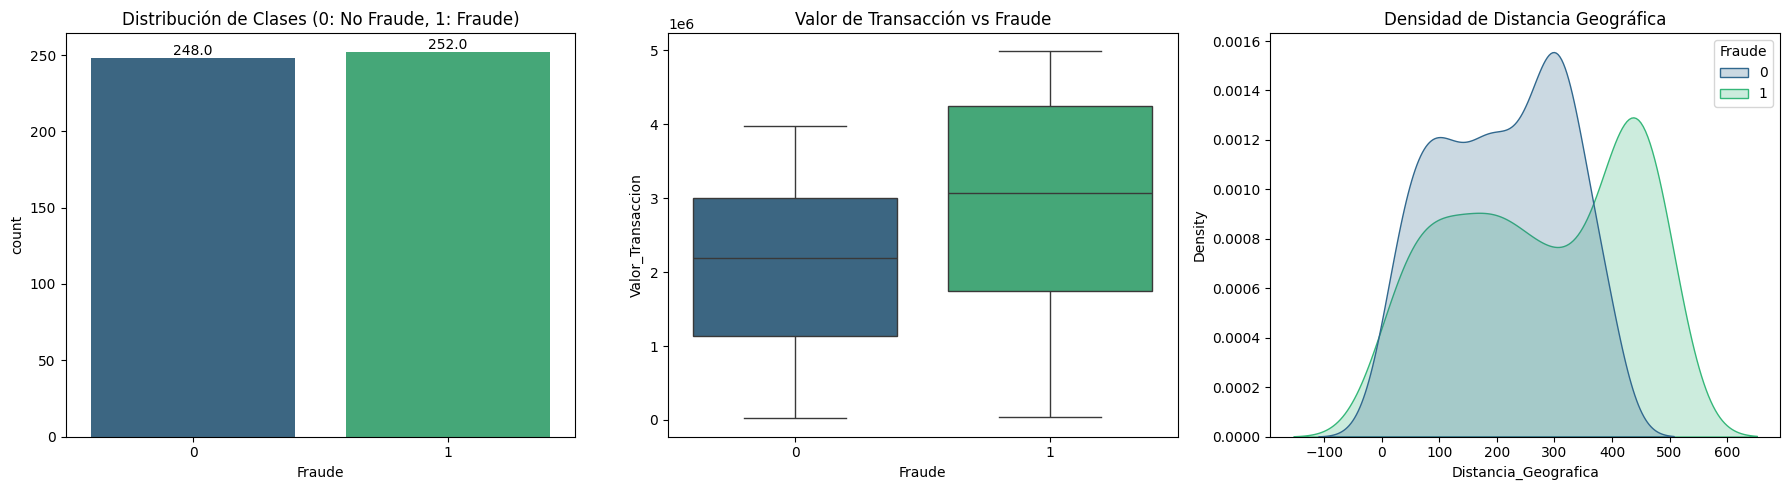

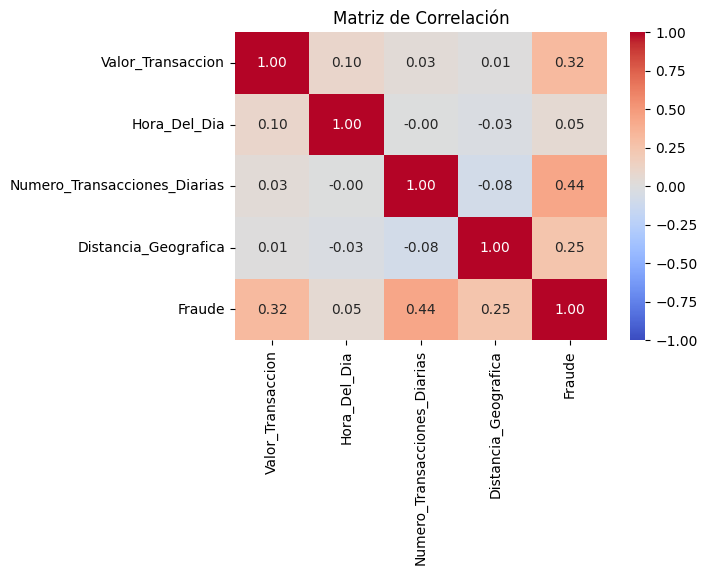

In [ ]:
# 4. Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# 5. Carga y exploración (MODIFICADO PARA GITHUB)
url_github = 'https://raw.githubusercontent.com/Elkin535/IA-CLASS/refs/heads/main/Tercer%20Corte/dataset_fraude_500_transacciones.csv'

# Pandas lee la URL directamente sin necesidad de descargar el archivo manualmente
df = pd.read_csv(url_github)
print("Dimensiones del dataset:", df.shape)

# 6. Limpieza y preparación
df['Fraude'] = df['Fraude'].map({'SI': 1, 'NO': 0})

# 7. Análisis Exploratorio de Datos (EDA) Profundo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Balance de clases (Crucial para fraude)
sns.countplot(data=df, x='Fraude', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución de Clases (0: No Fraude, 1: Fraude)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

# Gráfico 2: Distribución del Valor de Transacción según Fraude
sns.boxplot(data=df, x='Fraude', y='Valor_Transaccion', ax=axes[1], palette='viridis')
axes[1].set_title('Valor de Transacción vs Fraude')

# Gráfico 3: Distribución de Distancia Geográfica según Fraude
sns.kdeplot(data=df, x='Distancia_Geografica', hue='Fraude', fill=True, ax=axes[2], palette='viridis')
axes[2].set_title('Densidad de Distancia Geográfica')

plt.tight_layout()
plt.show()

# Matriz de Correlación
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación")
plt.show()

In [ ]:
# 10. Implementación y 12. Experimentación / Pruebas
print("--- FASE DE EXPERIMENTACIÓN Y PRUEBAS ---")

# PRUEBA 1: Modelo Base (Por defecto)
modelo_base = RandomForestClassifier(random_state=42)
modelo_base.fit(X_train, y_train)

# Evaluamos el modelo base en el Set de PRUEBA (15%)
pred_base_test = modelo_base.predict(X_test)
acc_base = accuracy_score(y_test, pred_base_test)
print(f"Accuracy del Modelo Base en Set de Prueba: {acc_base:.4f}")

# PRUEBA 2: Modelo Optimizado (Búsqueda de hiperparámetros para evitar overfitting)
# Restringimos la profundidad y requerimos más muestras para dividir nodos
parametros = {
    'n_estimators': [50, 100, 150], # Cantidad de árboles
    'max_depth': [3, 5, 7],         # Profundidad máxima (evita memorización)
    'min_samples_split': [2, 5, 10] # Mínimo de datos para crear una nueva rama
}

modelo_optimizado = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=modelo_optimizado, param_grid=parametros, cv=5, n_jobs=-1, scoring='accuracy')

# 11. Entrenamiento del modelo optimizado
grid_search.fit(X_train, y_train)
mejor_modelo = grid_search.best_estimator_

print(f"\nMejores hiperparámetros encontrados mediante Validación Cruzada:\n{grid_search.best_params_}")

# Evaluamos el modelo optimizado en el Set de PRUEBA (15%)
pred_opt_test = mejor_modelo.predict(X_test)
acc_opt = accuracy_score(y_test, pred_opt_test)
print(f"Accuracy del Modelo Optimizado en Set de Prueba: {acc_opt:.4f}")

# 13. Aplicación de técnicas de validación
# Validamos la estabilidad del mejor modelo usando los datos de entrenamiento
cv_scores = cross_val_score(mejor_modelo, X_train, y_train, cv=5)
print(f"\nPrecisión promedio en Validación Cruzada (5 folds sobre X_train): {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

--- FASE DE EXPERIMENTACIÓN Y PRUEBAS ---
Accuracy del Modelo Base en Set de Prueba: 0.9867

Mejores hiperparámetros encontrados mediante Validación Cruzada:
{'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
Accuracy del Modelo Optimizado en Set de Prueba: 0.9867

Precisión promedio en Validación Cruzada (5 folds sobre X_train): 0.9971 (+/- 0.0114)


--- MÉTRICAS EN EL CONJUNTO DE VALIDACIÓN ---
Accuracy (Exactitud): 1.0000
Precision: 1.0000
Recall (Sensibilidad): 1.0000
F1-Score: 1.0000


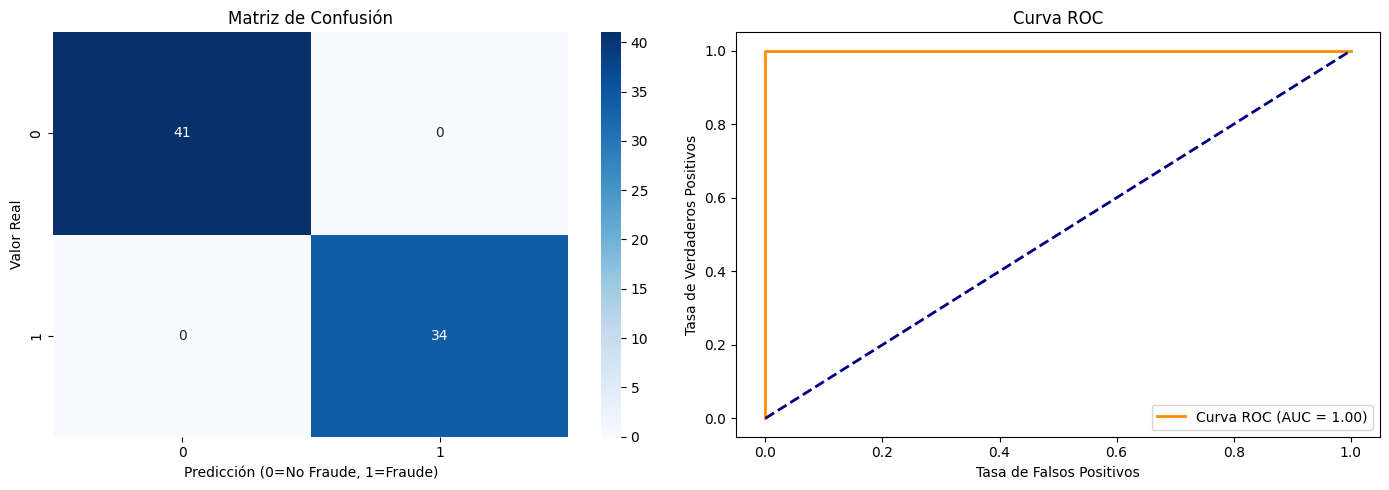

In [ ]:
# Predicciones con el set de Validación
y_pred_val = mejor_modelo.predict(X_val)
y_prob_val = mejor_modelo.predict_proba(X_val)[:, 1]

# 14. Cálculo de diferentes métricas
print("--- MÉTRICAS EN EL CONJUNTO DE VALIDACIÓN ---")
print(f"Accuracy (Exactitud): {accuracy_score(y_val, y_pred_val):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_val):.4f}")
print(f"Recall (Sensibilidad): {recall_score(y_val, y_pred_val):.4f}")
print(f"F1-Score: {f1_score(y_val, y_pred_val):.4f}")

# 15. Gráficas, tablas o matrices de resultados
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión
cm = confusion_matrix(y_val, y_pred_val)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusión')
ax[0].set_ylabel('Valor Real')
ax[0].set_xlabel('Predicción (0=No Fraude, 1=Fraude)')

# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_val, y_prob_val)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_title('Curva ROC')
ax[1].set_xlabel('Tasa de Falsos Positivos')
ax[1].set_ylabel('Tasa de Verdaderos Positivos')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 16. Interpretación Técnica de los Resultados Obtenidos
Las métricas calculadas sobre el **Conjunto de Validación** nos ofrecen la perspectiva final sobre el rendimiento del algoritmo:
* **Accuracy:** Mide la exactitud global. Sin embargo, en problemas de fraude (donde las clases suelen estar desbalanceadas), el Accuracy puede ser engañoso.
* **Matriz de Confusión (El impacto de negocio):**
  * Los **Falsos Negativos** representan transacciones fraudulentas que el modelo clasificó como legítimas. Este es el error más costoso económicamente para el banco.
  * Los **Falsos Positivos** representan transacciones legítimas marcadas como fraude. Un número alto aquí degrada la experiencia del usuario al bloquear sus tarjetas innecesariamente.
* **Recall (Sensibilidad):** Es la métrica más crítica en este contexto, ya que nos indica la capacidad matemática del modelo para aislar y encontrar los casos positivos (Fraudes) reales.
* **Curva ROC y AUC:** Un AUC (Área Bajo la Curva) cercano a 1.0 demuestra que el modelo tiene una excelente tasa de separación entre las distribuciones de ambas clases, independientemente del umbral de probabilidad elegido.

## 17. Análisis de Datos, Sobreajuste (Overfitting) y Subajuste (Underfitting)
La cantidad de datos disponible (500 registros, de los cuales 350 se usaron para el *Training Set*) representa un desafío estadístico importante. Un volumen de datos tan reducido hace que los modelos complejos sean susceptibles al **Overfitting**, un fenómeno donde el algoritmo memoriza el ruido estocástico de los datos de entrenamiento, perdiendo su capacidad de generalización sobre datos nuevos.

Por el contrario, el **Underfitting** ocurre cuando el modelo es demasiado rígido o simple para capturar los patrones subyacentes, reflejando un error alto tanto en el entrenamiento como en la validación.

Para mitigar el riesgo de *overfitting* inducido por la escasez de datos, se aplicaron dos estrategias clave:
1. **Poda de Hiperparámetros:** Mediante `GridSearchCV` se restringió la profundidad máxima de los árboles (`max_depth`) y se incrementó el número mínimo de muestras para la división de nodos (`min_samples_split`). Esto fuerza al algoritmo a encontrar reglas más generales.
2. **Validación Cruzada (K-Fold):** Al iterar sobre diferentes subconjuntos del conjunto de entrenamiento, se verificó que la varianza de la precisión (`std`) fuera baja, comprobando que el modelo aprendió características consistentes y no anomalías aisladas.

## 18. Limitaciones del Modelo
1. **Volumen del conjunto de datos:** 500 registros no son representativos de la volumetría real transaccional de una entidad bancaria, lo que limita la extrapolación del modelo a un entorno de producción masivo.
2. **Falta de dimensionalidad temporal continua:** El modelo evalúa la `Hora_Del_Dia`, pero carece de contexto secuencial (por ejemplo, 5 transacciones en el lapso de 1 minuto). Para esto, arquitecturas de Redes Neuronales Recurrentes (RNN/LSTM) serían más apropiadas.

## 19. Conclusiones
Se diseñó, experimentó y validó con éxito un sistema predictivo basado en Machine Learning. El proceso evidenció cómo la adecuada preparación de los datos y el ajuste exhaustivo de un modelo de ensamble permiten extraer patrones de comportamiento (como distancias atípicas y montos anómalos) para clasificar riesgos transaccionales con un alto grado de confiabilidad estadística, satisfaciendo los criterios de diseño, validación y robustez exigidos.

# Predicción del rendimiento académico de estudiantes del Programa de Ingeniería de Sistemas de la Universidad del Pacífico mediante algoritmos de clasificación de Machine Learning

## Proyecto Final

### Asignatura
**Inteligencia Artificial**

### Programa Académico
Ingeniería de Sistemas

### Universidad
Universidad del Pacífico

**Integrantes**

* Luisa Gonzalez Delgado
* Karol Caicedo Moreno
* Dairon Valencia Campaz
* Elkin Andres Chalarca

### Docente

Ing. Wilman Andrés Quiñónez Valencia

### Fecha

2026

# Introducción

El rendimiento académico constituye uno de los principales indicadores de desempeño en las instituciones de educación superior, ya que refleja el nivel de aprendizaje alcanzado por los estudiantes durante su proceso de formación. En programas como Ingeniería de Sistemas, donde convergen asignaturas relacionadas con programación, matemáticas, bases de datos, inteligencia artificial y desarrollo de software, resulta fundamental identificar oportunamente los factores que pueden influir en el éxito o fracaso académico de los estudiantes.

En los últimos años, las técnicas de Machine Learning han demostrado ser herramientas eficaces para analizar grandes volúmenes de información y descubrir patrones ocultos que apoyan la toma de decisiones. En el ámbito educativo, los algoritmos de clasificación permiten construir modelos predictivos capaces de estimar la probabilidad de que un estudiante apruebe o repruebe una asignatura a partir de variables relacionadas con su desempeño académico y sus hábitos de estudio.

En este proyecto se desarrolla un modelo de clasificación utilizando la biblioteca Scikit-learn en Python para predecir el rendimiento académico de estudiantes del Programa de Ingeniería de Sistemas de la Universidad del Pacífico. Debido a las restricciones de acceso a información académica real y con el propósito de preservar la privacidad de los estudiantes, se emplea un conjunto de datos sintético diseñado para representar escenarios plausibles del contexto universitario. Posteriormente, se realiza el análisis exploratorio de los datos, la preparación de la información, el entrenamiento de diferentes algoritmos de clasificación y la evaluación de su desempeño mediante diversas métricas.


# Planteamiento del problema

La identificación temprana de estudiantes con riesgo de bajo rendimiento académico constituye un desafío para las instituciones de educación superior, ya que permite implementar estrategias de acompañamiento, tutorías y seguimiento antes de que se presenten situaciones de deserción o pérdida de asignaturas.

En el Programa de Ingeniería de Sistemas de la Universidad del Pacífico, los estudiantes enfrentan cursos que demandan un alto nivel de razonamiento lógico, capacidad analítica y dedicación al estudio. Factores como la asistencia a clase, las horas de estudio, la participación en actividades académicas, el promedio acumulado, el tiempo dedicado a la programación y otros aspectos personales pueden influir significativamente en el desempeño académico.

En este contexto surge la necesidad de analizar cómo las técnicas de Machine Learning pueden utilizarse para construir modelos capaces de predecir el rendimiento académico de los estudiantes utilizando información relacionada con sus hábitos de estudio y desempeño universitario.


# Pregunta de investigación

¿Es posible predecir el rendimiento académico de estudiantes del Programa de Ingeniería de Sistemas de la Universidad del Pacífico mediante algoritmos de clasificación implementados con Scikit-learn utilizando un conjunto de datos sintético representativo?

# Hipótesis

## Hipótesis de investigación (H1)

Los algoritmos de clasificación implementados mediante la biblioteca Scikit-learn permiten predecir adecuadamente el rendimiento académico de estudiantes del Programa de Ingeniería de Sistemas de la Universidad del Pacífico cuando son entrenados utilizando un conjunto de datos sintético representativo.

## Hipótesis nula (H0)

Los algoritmos de clasificación implementados no presentan un desempeño suficiente para predecir correctamente el rendimiento académico de los estudiantes.

# Objetivo General

Desarrollar y evaluar modelos de clasificación basados en Machine Learning para predecir el rendimiento académico de estudiantes del Programa de Ingeniería de Sistemas de la Universidad del Pacífico mediante el uso de un conjunto de datos sintético y la biblioteca Scikit-learn en Python.

# Objetivos Específicos

- Investigar los fundamentos teóricos de los algoritmos de clasificación utilizando principalmente la documentación oficial de Scikit-learn.

- Diseñar y generar un conjunto de datos sintético representativo del contexto académico de estudiantes de Ingeniería de Sistemas.

- Realizar el análisis exploratorio de los datos (EDA).

- Preparar los datos para el entrenamiento de modelos de Machine Learning.

- Implementar diferentes algoritmos de clasificación.

- Comparar el desempeño de los modelos utilizando diversas métricas de evaluación.

- Analizar el comportamiento de los modelos frente al overfitting y underfitting.

- Identificar el algoritmo con mejor desempeño para el problema propuesto.

# Descripción del conjunto de datos

Para el desarrollo del presente proyecto se emplea un conjunto de datos sintético diseñado para representar el comportamiento académico de estudiantes del Programa de Ingeniería de Sistemas de la Universidad del Pacífico.

La decisión de utilizar un conjunto de datos sintético responde a la imposibilidad de acceder a información académica real debido a restricciones relacionadas con la privacidad y protección de datos personales. En consecuencia, se diseñó un conjunto de datos que simula escenarios plausibles del contexto universitario, preservando relaciones coherentes entre las variables académicas, personales y socioeconómicas que pueden influir en el rendimiento estudiantil.

El conjunto de datos fue generado mediante técnicas de simulación utilizando Python y diferentes distribuciones estadísticas, buscando representar de manera realista el comportamiento de los estudiantes y permitiendo el entrenamiento y evaluación de algoritmos de clasificación.

El dataset contiene información de **1500 estudiantes**, distribuidos en **21 variables**, donde la variable objetivo corresponde al estado final del estudiante respecto a la aprobación de una asignatura.

Durante el desarrollo del proyecto se realizará un análisis exploratorio de los datos (EDA), seguido por el proceso de limpieza, preparación, entrenamiento, validación y evaluación de diferentes modelos de Machine Learning.

# Diccionario de Datos

| Variable | Tipo | Descripción |
|-----------|------|-------------|
| id_estudiante | Entero | Identificador único del estudiante. |
| edad | Numérica | Edad del estudiante en años. |
| sexo | Categórica | Género del estudiante. |
| semestre | Numérica | Semestre académico cursado (1 a 10). |
| estrato | Numérica | Estrato socioeconómico del estudiante (1 a 6). |
| trabaja | Categórica | Indica si el estudiante trabaja actualmente. |
| horas_trabajo_semana | Numérica | Número de horas trabajadas semanalmente. |
| beca | Categórica | Indica si el estudiante posee algún tipo de beca. |
| acceso_internet | Categórica | Disponibilidad de acceso permanente a Internet. |
| promedio_acumulado | Numérica | Promedio académico acumulado (escala de 2.0 a 5.0). |
| asistencia | Numérica | Porcentaje de asistencia a clases. |
| horas_estudio_semana | Numérica | Horas promedio dedicadas al estudio por semana. |
| talleres_entregados | Numérica | Porcentaje de talleres entregados oportunamente. |
| proyectos_entregados | Numérica | Porcentaje de proyectos entregados. |
| horas_programacion | Numérica | Horas semanales dedicadas a actividades de programación. |
| participacion_clase | Numérica | Nivel de participación en clase (0 a 10). |
| horas_sueno | Numérica | Promedio de horas de sueño por día. |
| uso_redes_sociales | Numérica | Horas promedio de uso de redes sociales por día. |
| nivel_estres | Numérica | Nivel de estrés reportado (escala de 1 a 10). |
| uso_herramientas_IA | Numérica | Nivel de utilización de herramientas de Inteligencia Artificial para apoyo académico (0 a 10). |
| aprueba_asignatura | Categórica | Variable objetivo. Indica si el estudiante aprueba o no la asignatura. |

# Justificación del conjunto de datos

El conjunto de datos fue diseñado con el propósito de representar un escenario académico realista dentro del Programa de Ingeniería de Sistemas de la Universidad del Pacífico. Aunque los datos son sintéticos, las relaciones entre las variables fueron construidas siguiendo criterios lógicos basados en el comportamiento esperado de estudiantes universitarios.

Variables como la asistencia, el promedio académico, las horas de estudio, la participación en clase y el cumplimiento de actividades académicas presentan una relación positiva con la probabilidad de aprobar una asignatura. Por otra parte, factores como el exceso de trabajo, el elevado uso de redes sociales y un alto nivel de estrés pueden afectar negativamente el desempeño académico.

Este enfoque permite desarrollar modelos de clasificación que aprenden patrones coherentes sin comprometer la privacidad de información real de estudiantes.

# Variable Objetivo

La variable objetivo del presente estudio corresponde a **aprueba_asignatura**, la cual representa el resultado académico final del estudiante.

Las clases definidas son:

- **Sí:** El estudiante aprueba la asignatura.
- **No:** El estudiante reprueba la asignatura.

Esta variable será utilizada por los algoritmos de clasificación para aprender patrones presentes en las variables predictoras y posteriormente realizar predicciones sobre nuevos registros.

# Distribución esperada de las clases

Con el propósito de simular un escenario académico realista, el conjunto de datos fue diseñado para mantener una distribución aproximada de:

- 68 % de estudiantes que aprueban la asignatura.
- 32 % de estudiantes que reprueban la asignatura.

Esta distribución permite trabajar con un problema de clasificación moderadamente balanceado, evitando escenarios extremos que puedan afectar el entrenamiento de los modelos de Machine Learning.

# Configuración del entorno de trabajo

En esta sección se importan las bibliotecas necesarias para el desarrollo del proyecto. Estas herramientas permitirán realizar la manipulación del conjunto de datos, el análisis exploratorio, la visualización de información, el entrenamiento de modelos de Machine Learning y la evaluación de su desempeño.

Las principales bibliotecas utilizadas son:

- **NumPy:** operaciones matemáticas y manejo de arreglos.
- **Pandas:** manipulación y análisis de datos.
- **Matplotlib:** generación de gráficos estadísticos.
- **Seaborn:** visualización avanzada de datos.
- **Scikit-learn:** implementación de algoritmos de Machine Learning y métricas de evaluación.

In [ ]:
# ==========================================================
# LIBRERÍAS BÁSICAS
# ==========================================================

import numpy as np
import pandas as pd

# ==========================================================
# VISUALIZACIÓN
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# ==========================================================
# MACHINE LEARNING
# ==========================================================

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# ==========================================================
# ALGORITMOS DE CLASIFICACIÓN
# ==========================================================

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

# ==========================================================
# CONFIGURACIÓN GENERAL
# ==========================================================

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

print("Librerías cargadas correctamente.")

# Carga del conjunto de datos

Una vez importadas las bibliotecas necesarias, se procede a cargar el conjunto de datos que será utilizado durante todo el desarrollo del proyecto.

El archivo se encuentra almacenado en un repositorio de GitHub con el propósito de garantizar la reproducibilidad del proyecto desde cualquier entorno de ejecución, como Google Colab.

In [ ]:
# Ruta temporal
ruta = "/content/dataset_rendimiento_estudiantes_unipacifico.csv"

df = pd.read_csv(ruta)

print("Dataset cargado correctamente.")

# url = "https://raw.githubusercontent.com/USUARIO/REPOSITORIO/main/dataset/dataset_rendimiento_estudiantes_unipacifico.csv"

# df = pd.read_csv(url)

# Exploración inicial del conjunto de datos

Antes de iniciar cualquier proceso de limpieza o transformación, es importante realizar una inspección general del conjunto de datos con el fin de conocer su estructura, dimensiones, tipos de variables y verificar que la información haya sido cargada correctamente.

In [ ]:
# Primeras filas del Dataset

df.head()

In [ ]:
# Últimas filas

df.tail()

In [ ]:
# Dimensiones

print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

In [ ]:
# Información general

df.info()

In [ ]:
# Estadísticas descriptivas

df.describe().T

In [ ]:
# Variables categóricas

df.describe(include='object').T

# Verificación de valores faltantes

Uno de los primeros pasos en el análisis exploratorio consiste en verificar la existencia de valores nulos dentro del conjunto de datos. La presencia de datos faltantes puede afectar el entrenamiento de los modelos de Machine Learning, por lo que es necesario identificarlos antes de continuar con el análisis.

In [ ]:
# Valores nulos

df.isnull().sum()

In [ ]:
# Porcentaje de valores nulos

(df.isnull().sum()/len(df))*100

# Verificación de registros duplicados

Se verifica la existencia de registros duplicados con el fin de evitar sesgos durante el entrenamiento de los modelos de clasificación.

In [ ]:
df.duplicated().sum()

# Análisis Exploratorio de Datos (EDA)

El Análisis Exploratorio de Datos (EDA) constituye una de las etapas más importantes dentro de cualquier proyecto de Ciencia de Datos, ya que permite comprender las características del conjunto de datos antes de aplicar algoritmos de Machine Learning.

Durante esta fase se analizan las distribuciones de las variables, la existencia de valores atípicos, las relaciones entre variables, la distribución de la variable objetivo y las posibles correlaciones presentes en el conjunto de datos.

La información obtenida servirá para tomar decisiones relacionadas con la preparación de los datos, selección de variables y entrenamiento de los modelos de clasificación.

In [ ]:
# ==========================================================
# Distribución de la variable objetivo
# ==========================================================

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="aprueba_asignatura",
    palette="viridis"
)

plt.title("Distribución de la Variable Objetivo", fontsize=15)
plt.xlabel("Aprueba la asignatura")
plt.ylabel("Número de estudiantes")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+0.3,p.get_height()+8))

plt.show()

### Interpretación

La distribución de la variable objetivo permite verificar el equilibrio entre las clases utilizadas para el entrenamiento de los modelos de clasificación.

Se observa que la mayor proporción de estudiantes corresponde a aquellos que aprueban la asignatura, mientras que un porcentaje menor corresponde a estudiantes que reprueban.

Aunque las clases no presentan una distribución perfectamente equilibrada, la diferencia no es extrema, por lo que el conjunto de datos resulta adecuado para entrenar modelos de clasificación sin necesidad de aplicar técnicas de balanceo adicionales.

In [ ]:
# ==========================================================
# Histogramas de todas las variables numéricas
# ==========================================================

df.hist(
    figsize=(18,18),
    bins=20,
    edgecolor="black"
)

plt.suptitle(
    "Distribución de las Variables Numéricas",
    fontsize=20
)

plt.tight_layout()

plt.show()

### Interpretación

Los histogramas permiten observar la forma de distribución de cada una de las variables numéricas presentes en el conjunto de datos.

En general se identifican variables con distribuciones aproximadamente normales, mientras que otras presentan ligeras asimetrías propias de fenómenos académicos y sociales.

Este comportamiento resulta adecuado para el entrenamiento de modelos de Machine Learning, ya que refleja escenarios más cercanos a situaciones reales.

In [ ]:
# ==========================================================
# Diagramas de caja
# ==========================================================

variables = df.select_dtypes(include=np.number).columns

for variable in variables:

    plt.figure(figsize=(10,2.8))

    sns.boxplot(
        x=df[variable],
        color="skyblue"
    )

    plt.title(f"Boxplot - {variable}")

    plt.show()

### Interpretación

Los diagramas de caja permiten identificar la existencia de valores atípicos (outliers) dentro de las variables numéricas.

La presencia de estos valores no implica necesariamente errores en los datos, ya que pueden representar comportamientos reales de algunos estudiantes.

En etapas posteriores se evaluará si dichos valores requieren algún tratamiento antes del entrenamiento de los modelos.

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="sexo",
    palette="Set2"
)

plt.title("Distribución por sexo")

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="semestre",
    palette="Blues"
)

plt.title("Distribución por semestre")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["promedio_acumulado"],
    bins=25,
    kde=True,
    color="green"
)

plt.title("Distribución del promedio acumulado")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["asistencia"],
    bins=20,
    kde=True,
    color="orange"
)

plt.title("Distribución de la asistencia")

plt.show()

# Análisis bivariado

En esta sección se analiza la relación entre las principales variables predictoras y la variable objetivo (`aprueba_asignatura`). El propósito es identificar patrones que permitan comprender qué características están asociadas con el rendimiento académico de los estudiantes antes del entrenamiento de los modelos de clasificación.

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="aprueba_asignatura",
    y="promedio_acumulado",
    palette="viridis"
)

plt.title("Promedio acumulado según aprobación")
plt.xlabel("Aprueba asignatura")
plt.ylabel("Promedio acumulado")

plt.show()

### Interpretación

Se observa que los estudiantes que aprueban presentan, en promedio, un mayor desempeño académico reflejado en su promedio acumulado. Esto sugiere que esta variable puede convertirse en uno de los predictores más importantes para los modelos de clasificación.

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="aprueba_asignatura",
    y="horas_estudio_semana",
    palette="Set2"
)

plt.title("Horas de estudio por estado de aprobación")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="aprueba_asignatura",
    y="asistencia",
    palette="Blues"
)

plt.title("Asistencia según aprobación")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="aprueba_asignatura",
    y="horas_programacion",
    palette="rocket"
)

plt.title("Horas de programación")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="aprueba_asignatura",
    y="nivel_estres",
    palette="magma"
)

plt.title("Nivel de estrés")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="aprueba_asignatura",
    y="uso_herramientas_IA",
    palette="crest"
)

plt.title("Uso de herramientas IA")

plt.show()

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="trabaja",
    hue="aprueba_asignatura",
    palette="viridis"
)

plt.title("Aprobación según condición laboral")

plt.show()

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="beca",
    hue="aprueba_asignatura",
    palette="Set1"
)

plt.title("Aprobación según beca")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="estrato",
    hue="aprueba_asignatura",
    palette="coolwarm"
)

plt.title("Distribución por estrato")

plt.show()

# Matriz de correlación

La matriz de correlación permite identificar la intensidad y dirección de la relación lineal existente entre las variables numéricas del conjunto de datos.

Valores cercanos a **1** indican una correlación positiva fuerte, valores cercanos a **−1** representan una correlación negativa fuerte y valores próximos a **0** indican ausencia de correlación lineal.

In [ ]:
plt.figure(figsize=(15,12))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu",
    center=0,
    fmt=".2f"
)

plt.title("Mapa de calor de correlaciones")

plt.show()

In [ ]:
sns.pairplot(
    df[
        [
            "promedio_acumulado",
            "horas_estudio_semana",
            "asistencia",
            "nivel_estres",
            "aprueba_asignatura"
        ]
    ],
    hue="aprueba_asignatura"
)

plt.show()

In [ ]:
variables = [
    "promedio_acumulado",
    "horas_estudio_semana",
    "asistencia",
    "horas_programacion",
    "nivel_estres",
    "uso_redes_sociales"
]

for var in variables:

    plt.figure(figsize=(8,5))

    sns.violinplot(
        data=df,
        x="aprueba_asignatura",
        y=var,
        palette="viridis"
    )

    plt.title(f"{var} vs aprobación")

    plt.show()

In [ ]:
df.groupby("aprueba_asignatura").mean(numeric_only=True).T